In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
#import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data, local_phi_transformation

from helpers.models.DNN import count_parameters
from helpers.evaluation import run_eval_suite_BDTs
from helpers.plotting import plot_hists_1d, make_2d_plots
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector, build_xy_z_lookup, snap_z_to_detector_xy


#plt.style.use("../science.mplstyle")

In [3]:

num_BDTs = 1


with open("configs.yaml", "r") as f:
    configs = yaml.safe_load(f)

BIN_BOUND = configs["BIN_BOUND"]
NUM_BINS = configs["NUM_BINS"]
ALL_COLLECTIONS = configs["ALL_COLLECTIONS"]
FEATURE_ORDER = configs["FEATURE_ORDER"]
FEATURE_INDICES_DICT = configs["FEATURE_INDICES_DICT"]
PATH_TO_DATA_DIR = configs["PATH_TO_DATA_DIR"]

NUM_COND_INPUTS = 4
BASIS = "rphi"
log_vars = []

PATHS_TO_SAMPLES = {
    "OuterTrackerBarrelCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/OTBC_cond4/",
    "OuterTrackerEndcapCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/OTEC_cond4/",
    "InnerTrackerBarrelCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/ITBC_cond4/",
    "InnerTrackerEndcapCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/ITEC_cond4/",
    "VertexBarrelCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/VBC_cond4/",
    "VertexEndcapCollection": "/scratch/midway3/rmastand/muon_collider/zuko_outputs/VEC_cond4/",
                    }


In [4]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
feature_labels_dict = {}

for col_name in ALL_COLLECTIONS:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], BASIS, PATH_TO_DATA_DIR, 1, NUM_COND_INPUTS, FEATURE_ORDER)
    
    all_data_dir[col_name] = X

    # if use_local_phi:
    #     tmp = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    #     all_samples_dir[col_name] = local_phi_transformation(
    #                                     tmp, 
    #                                     layers=tmp[:,feature_indices_dict["layer"]],
    #                                     phi_index=tmp[:, 7] if "Barrel" in col_name else tmp[:, 8],
    #                                     collection=col_name, 
    #                                     direction="reverse",
    #                                     r_col=2,
    #                                     phi_col=3)
    all_samples_dir[col_name] = np.load(f"{PATHS_TO_SAMPLES[col_name]}/generated_samples.npy")


    feature_labels_dict[col_name] = feature_labels
    
    

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(all_data_dir[col_name].shape[1])}
    
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 

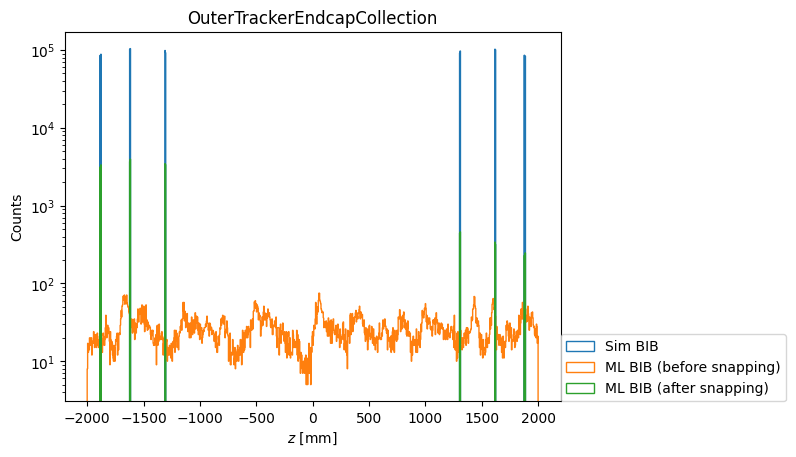

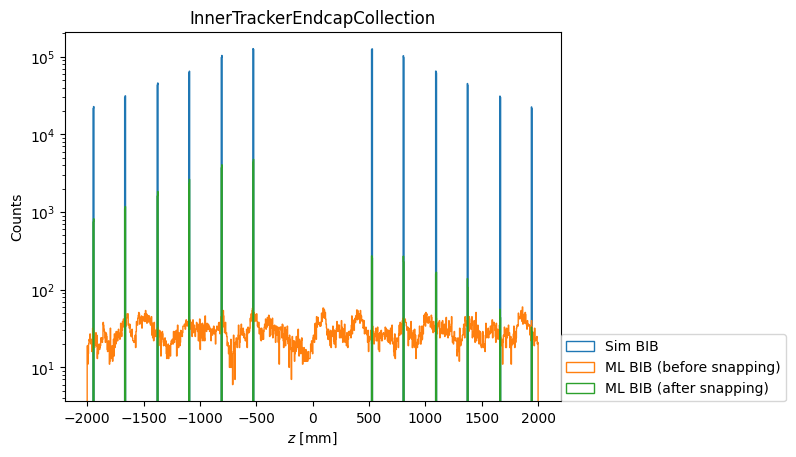

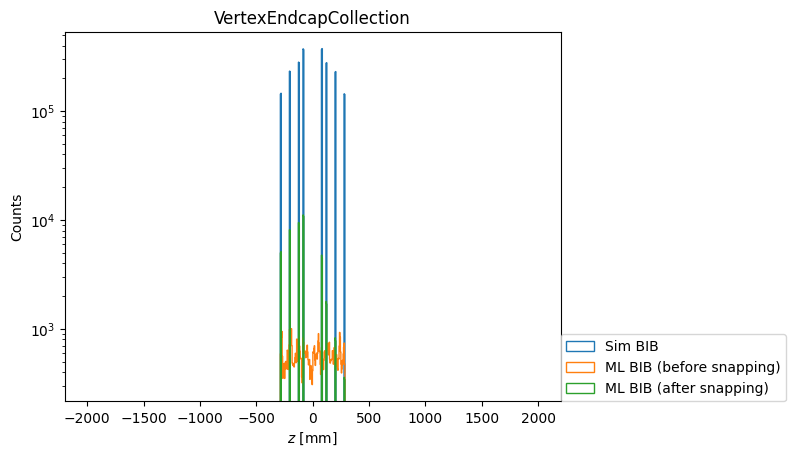

In [5]:
for col_name in ALL_COLLECTIONS:

    if "Endcap" in col_name:
        plt.figure()
    
        z_idx = FEATURE_INDICES_DICT["z"]
        side_idx = FEATURE_INDICES_DICT["side"]
        layer_idx = FEATURE_INDICES_DICT["layer"]
    
        # original samples
        z_samples = all_samples_dir[col_name][:, z_idx]
        sides = all_samples_dir[col_name][:, side_idx]
        layers = all_samples_dir[col_name][:, layer_idx]
    
    

        z_lookup = build_xy_z_lookup(
            all_data_dir[col_name],
            FEATURE_INDICES_DICT["side"],
            FEATURE_INDICES_DICT["layer"],
            FEATURE_INDICES_DICT["r"],
            FEATURE_INDICES_DICT["phi"],
            FEATURE_INDICES_DICT["z"],
        )


        plt.hist(
            all_data_dir[col_name][:, z_idx],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="Sim BIB"
        )

        plt.hist(
            all_samples_dir[col_name][:,FEATURE_INDICES_DICT["z"]],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="ML BIB (before snapping)"
        )

            

        z_samples_snapped =  snap_z_to_detector_xy(
            all_samples_dir[col_name][:, FEATURE_INDICES_DICT["r"]],
            all_samples_dir[col_name][:, FEATURE_INDICES_DICT["phi"]],
            sides,
            layers,
            z_lookup,
        )

        all_samples_dir[col_name][:,FEATURE_INDICES_DICT["z"]] = z_samples_snapped
    
        # plot truth vs snapped samples
        
    
        plt.hist(
            z_samples_snapped,
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="ML BIB (after snapping)"
        )

        
        plt.title(col_name)
        plt.yscale("log")
        plt.legend()
        plt.xlabel("$z$ [mm]")
        plt.ylabel("Counts")
        plt.legend(loc = (1,0))
        plt.show()



In [7]:
flow_samples_masked, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir, ALL_COLLECTIONS, NUM_COND_INPUTS, FEATURE_INDICES_DICT, stratify = False)



OuterTrackerBarrelCollection: 0.02590989453148814% of samples pass (17 after masking, 65612 before masking)
OuterTrackerEndcapCollection: 99.76463364715514% of samples pass (29247 after masking, 29316 before masking)
InnerTrackerBarrelCollection: 0.042026438450370594% of samples pass (33 after masking, 78522 before masking)
InnerTrackerEndcapCollection: 76.59482224699616% of samples pass (24734 after masking, 32292 before masking)
VertexBarrelCollection: 0.3499131088253253% of samples pass (149 after masking, 42582 before masking)
VertexEndcapCollection: 88.66660156726802% of samples pass (72641 after masking, 81926 before masking)


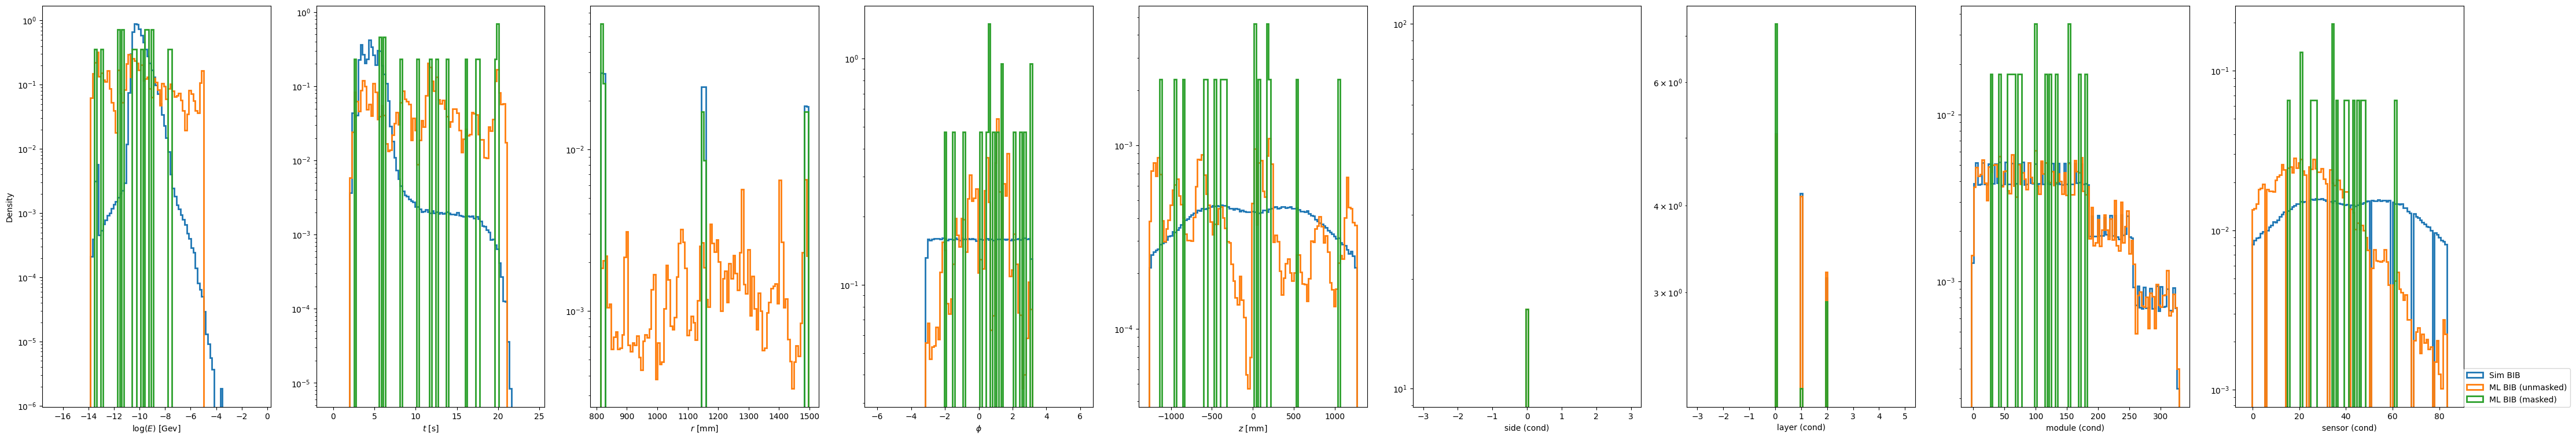

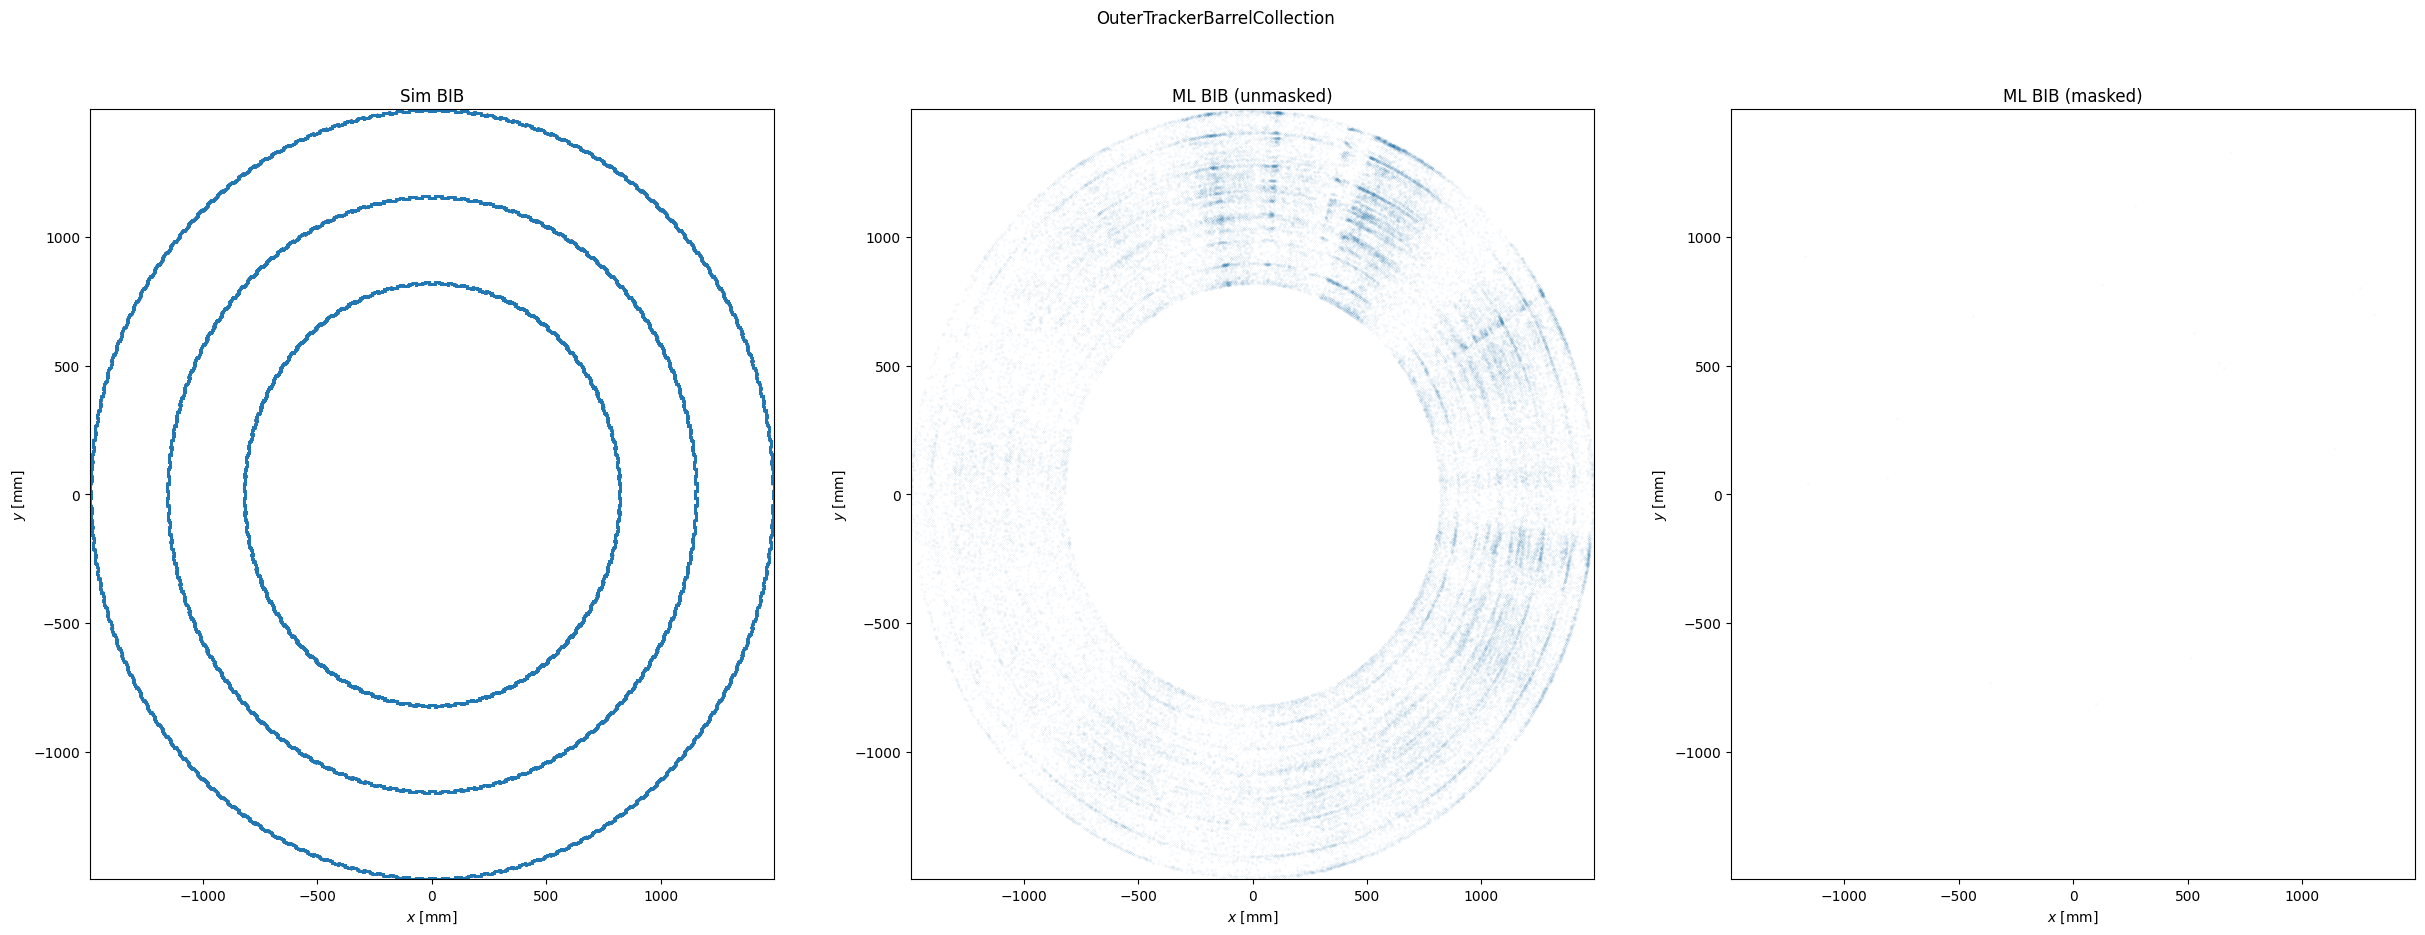

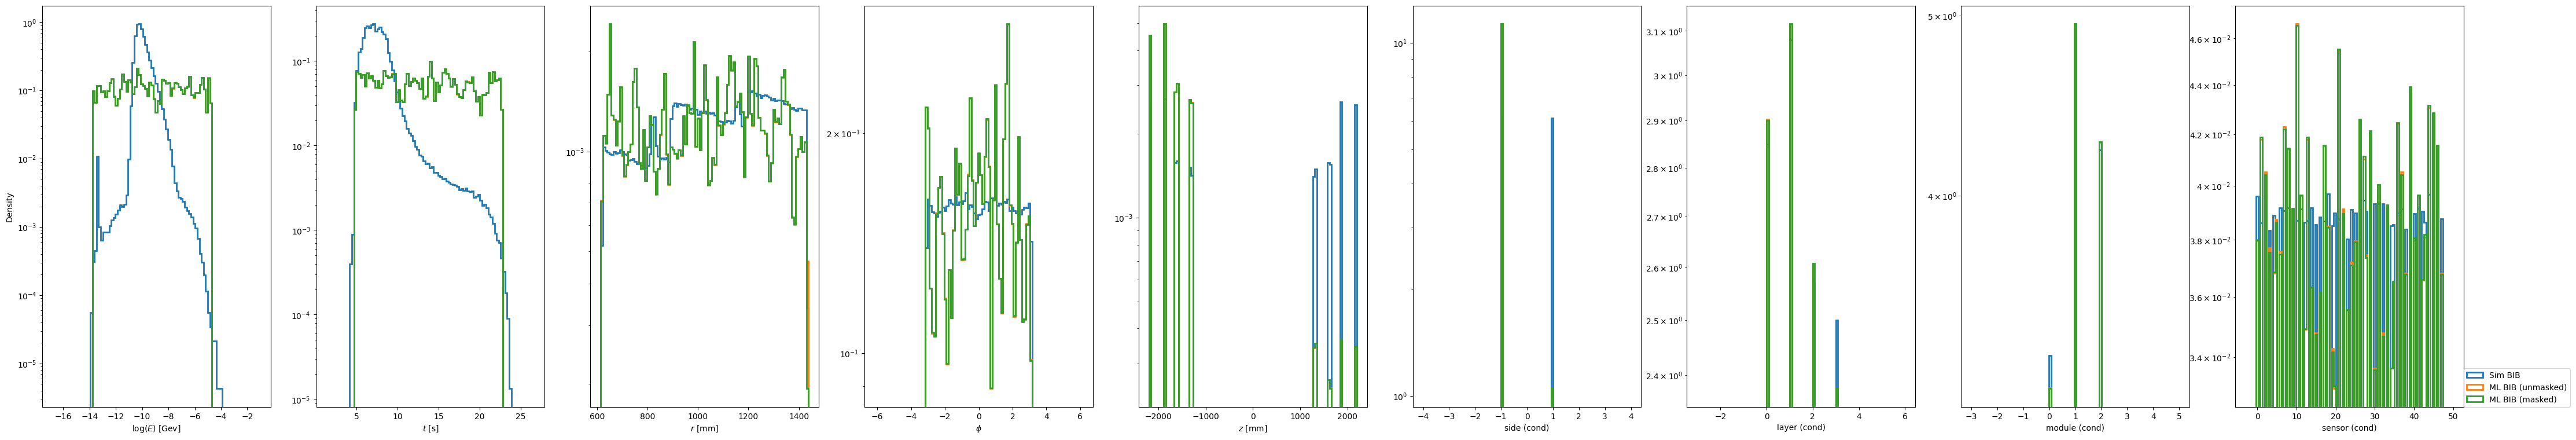

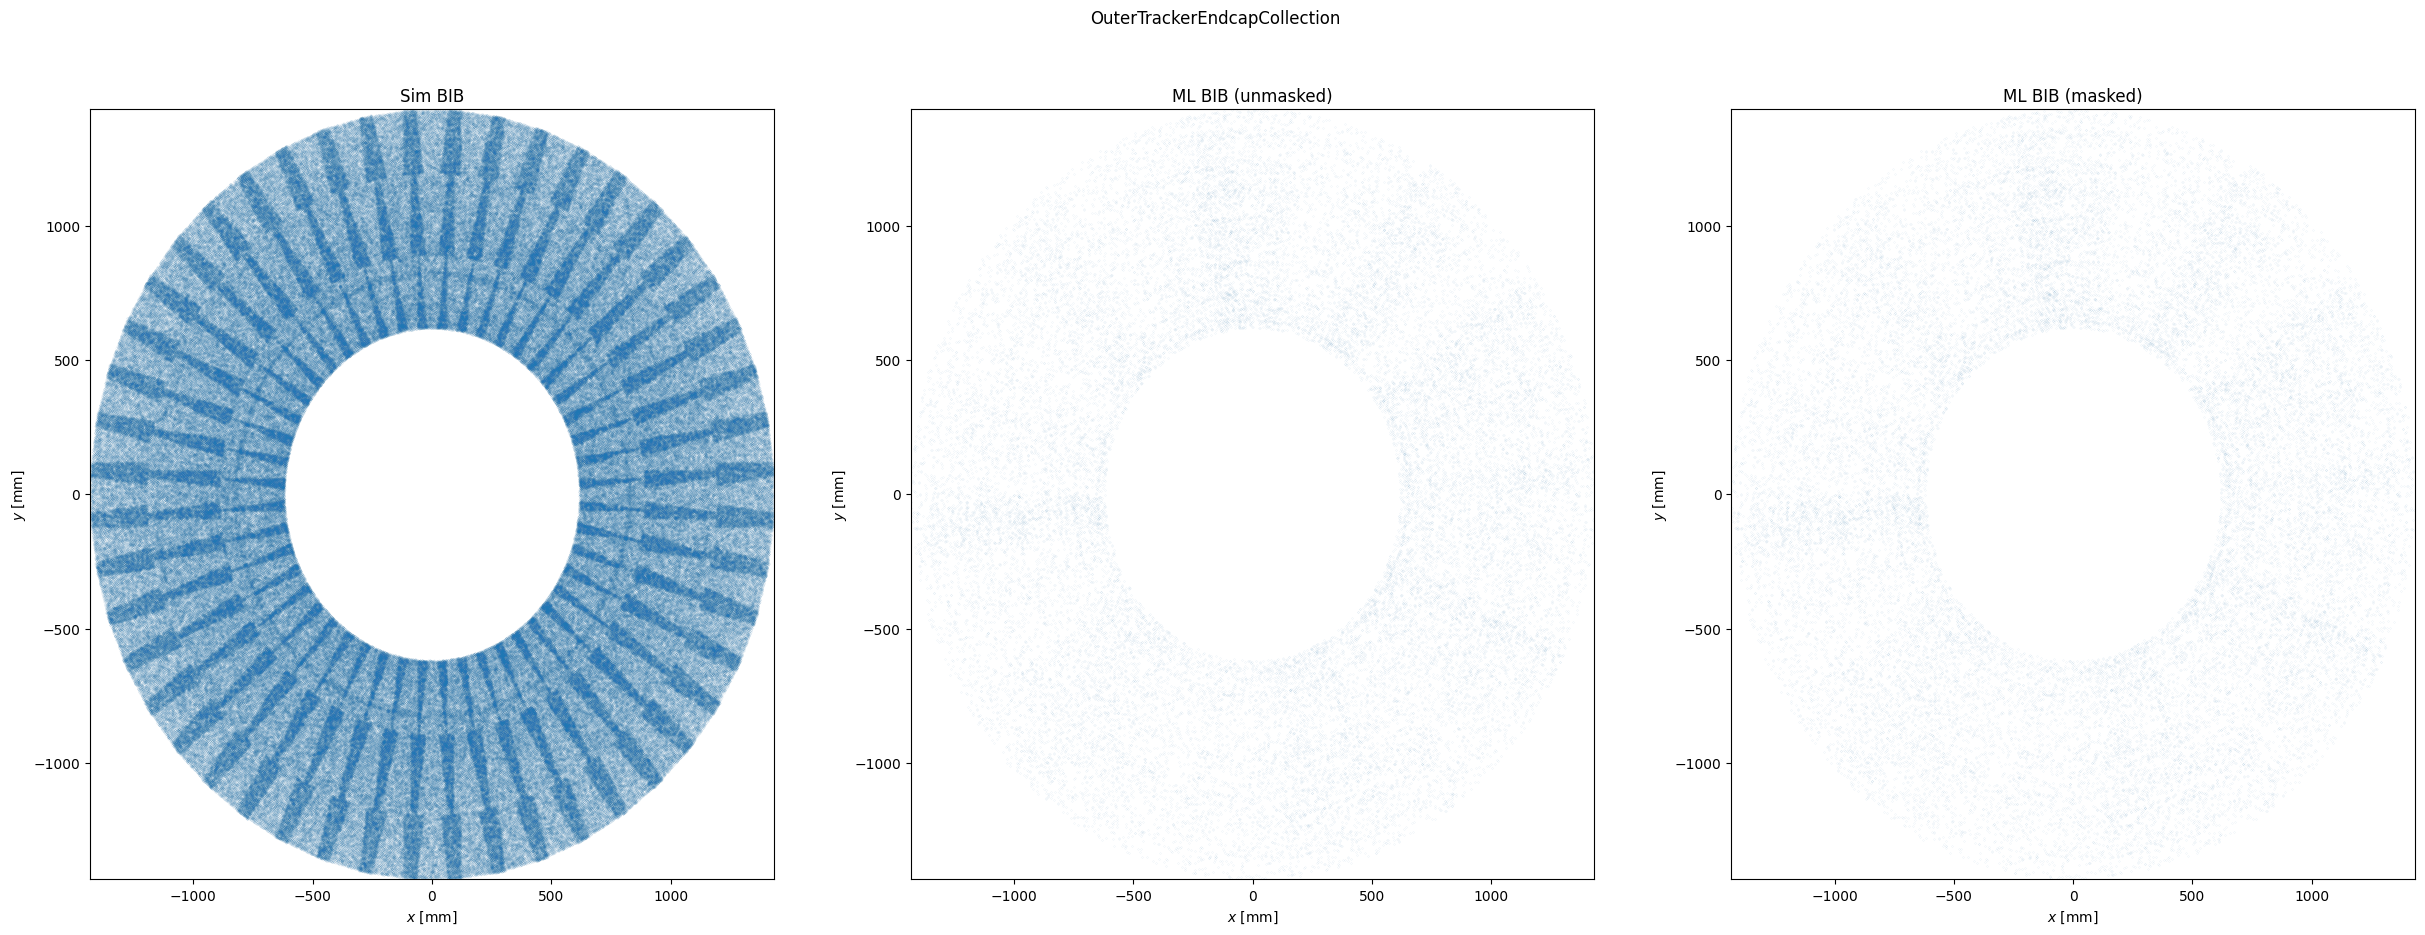

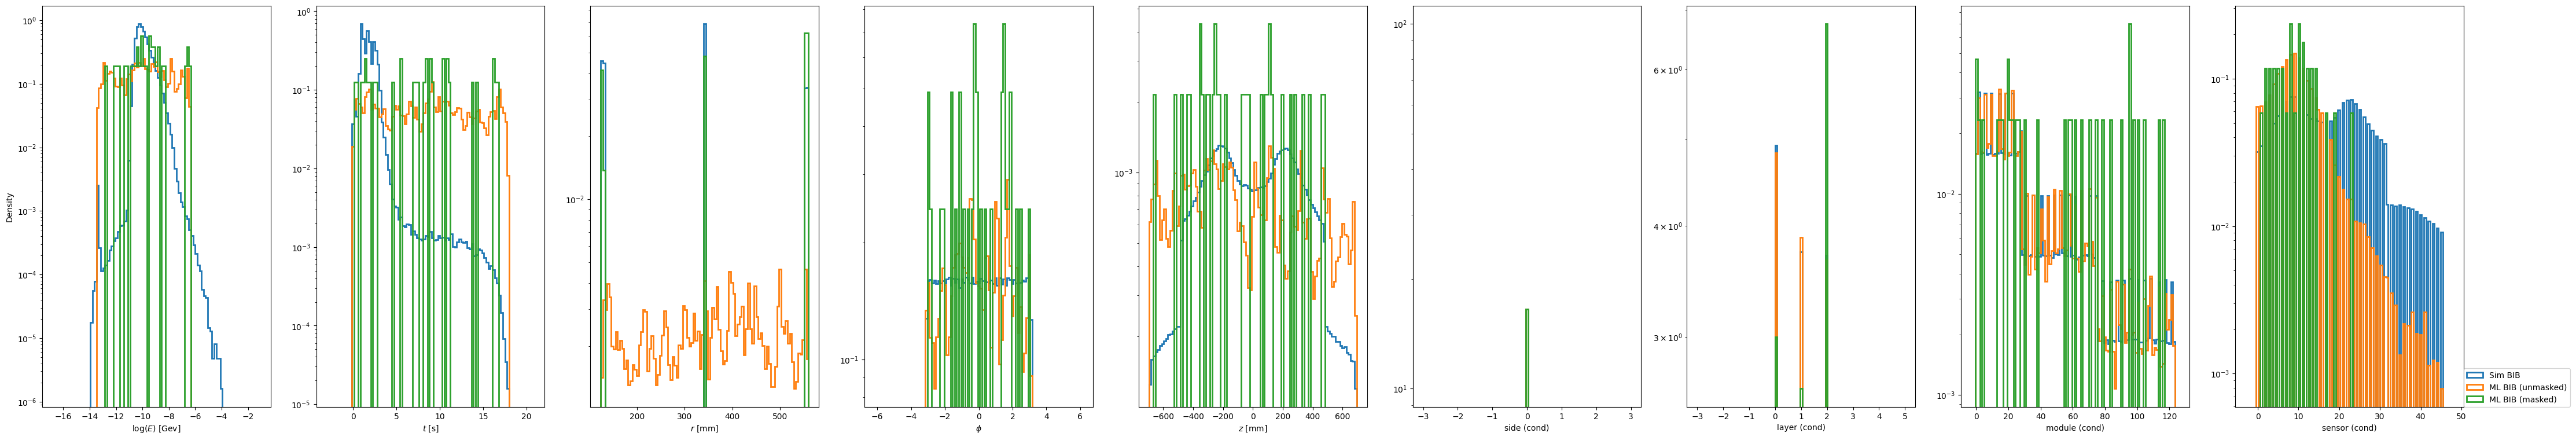

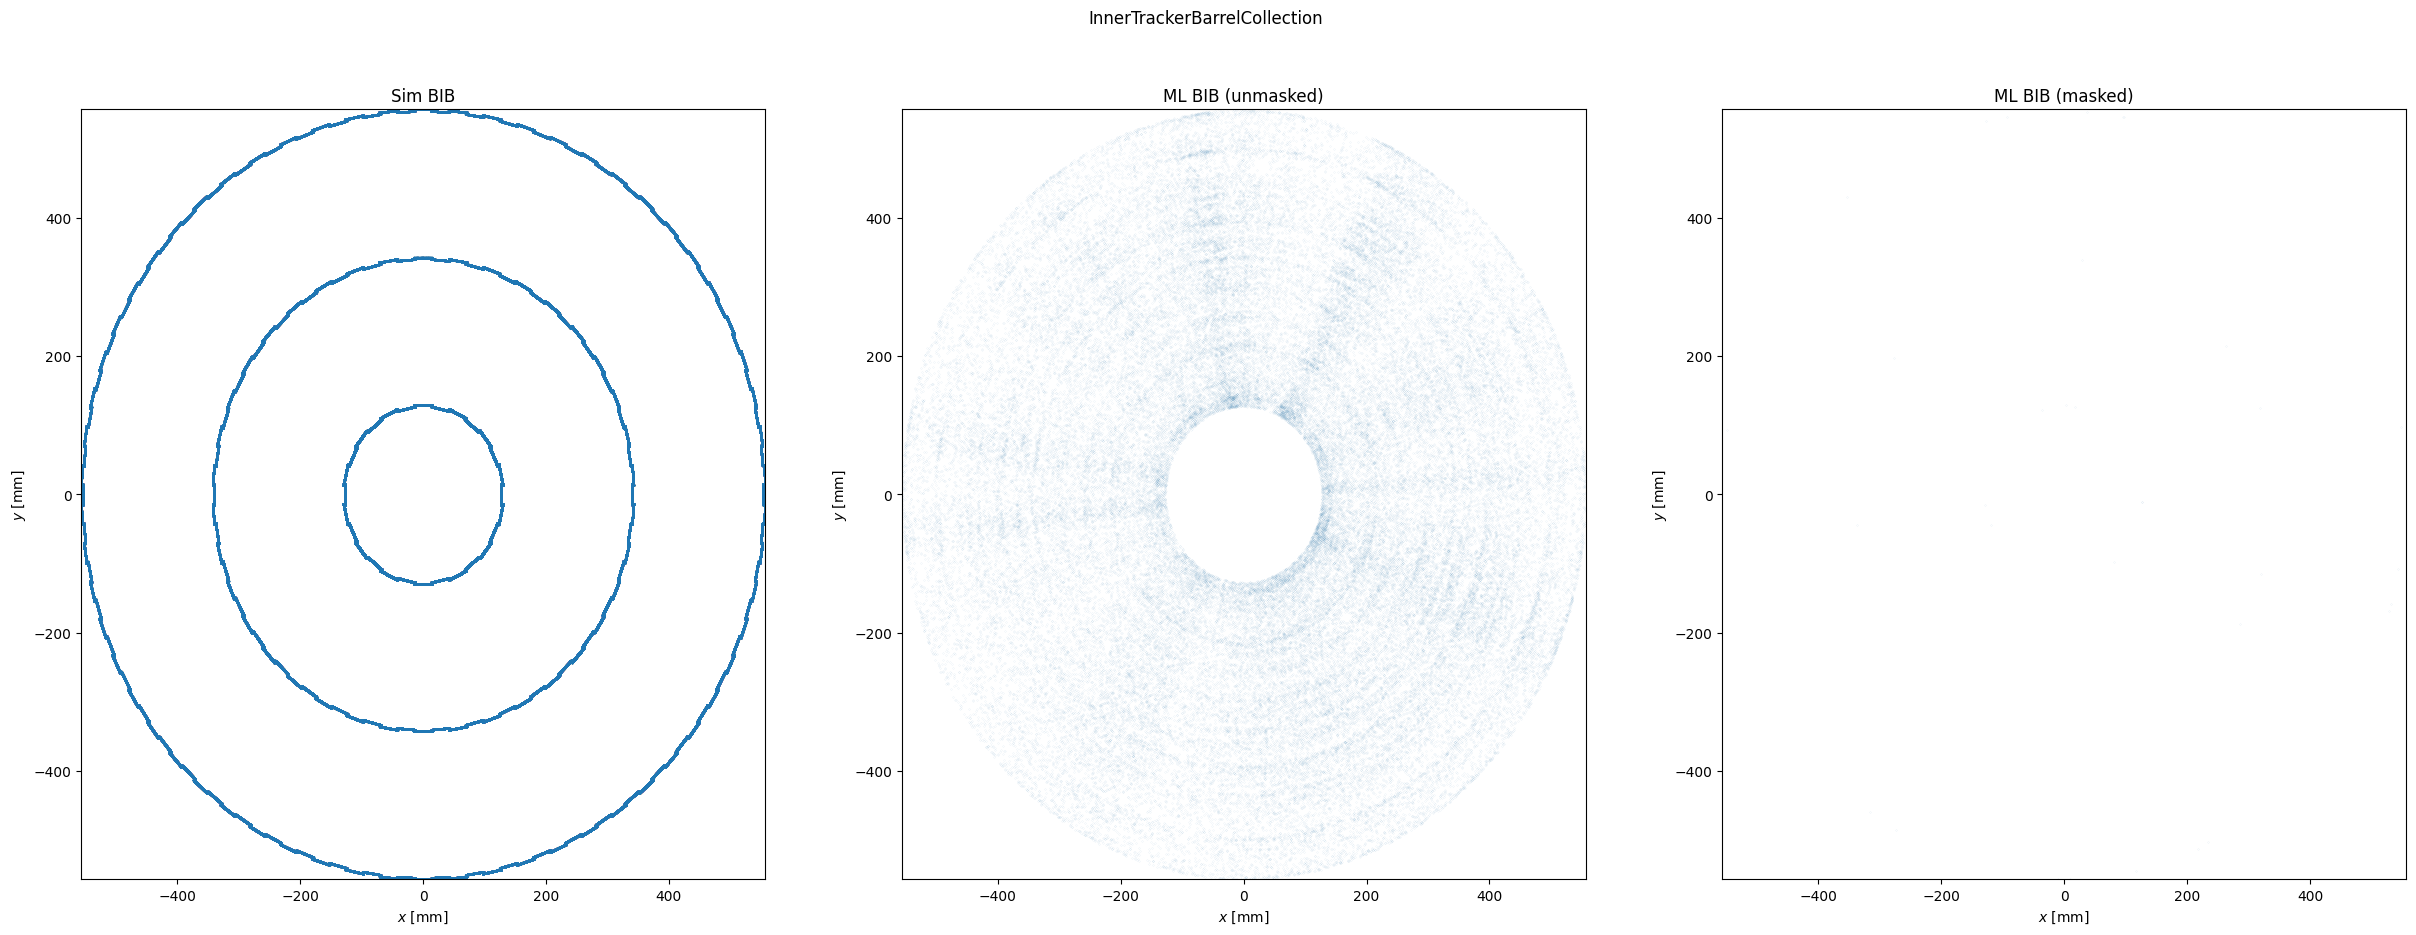

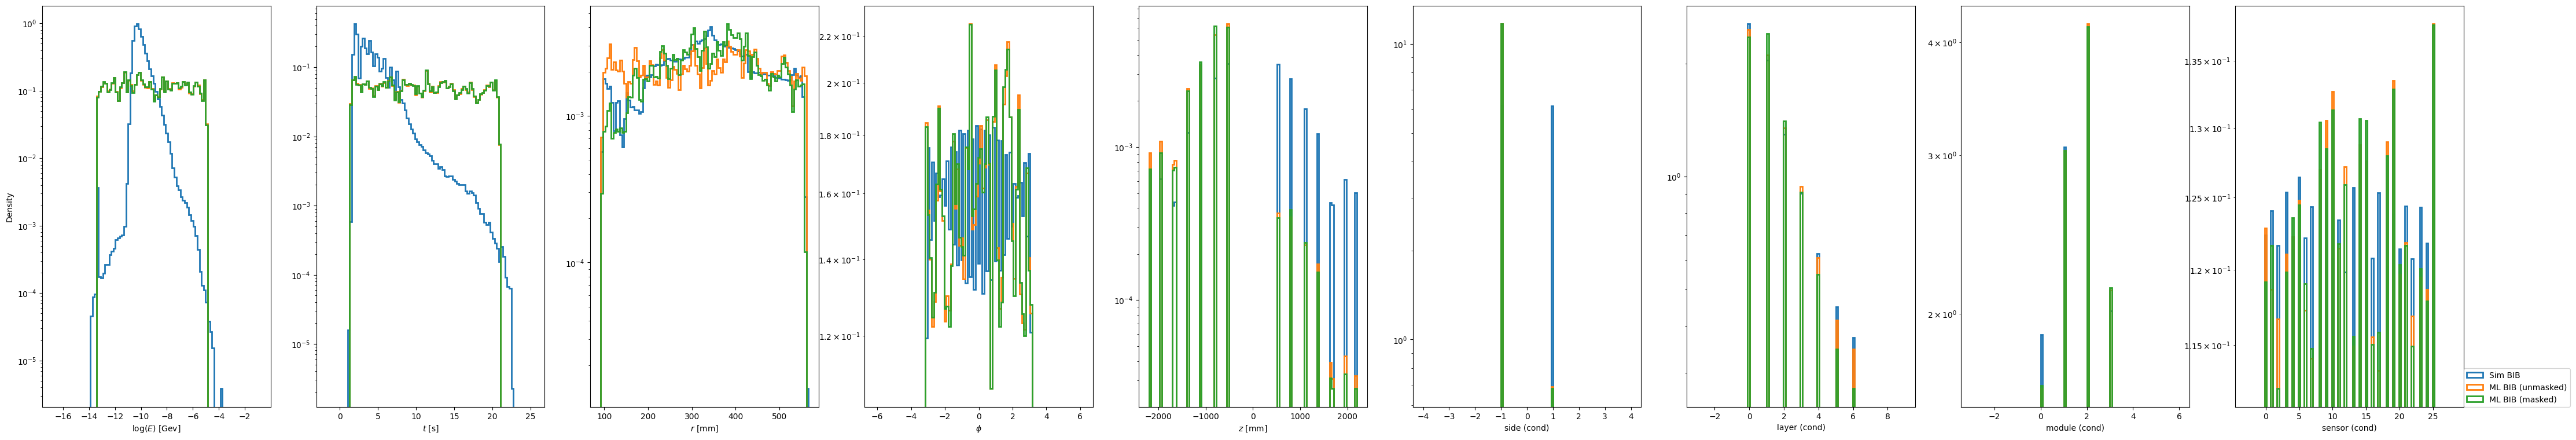

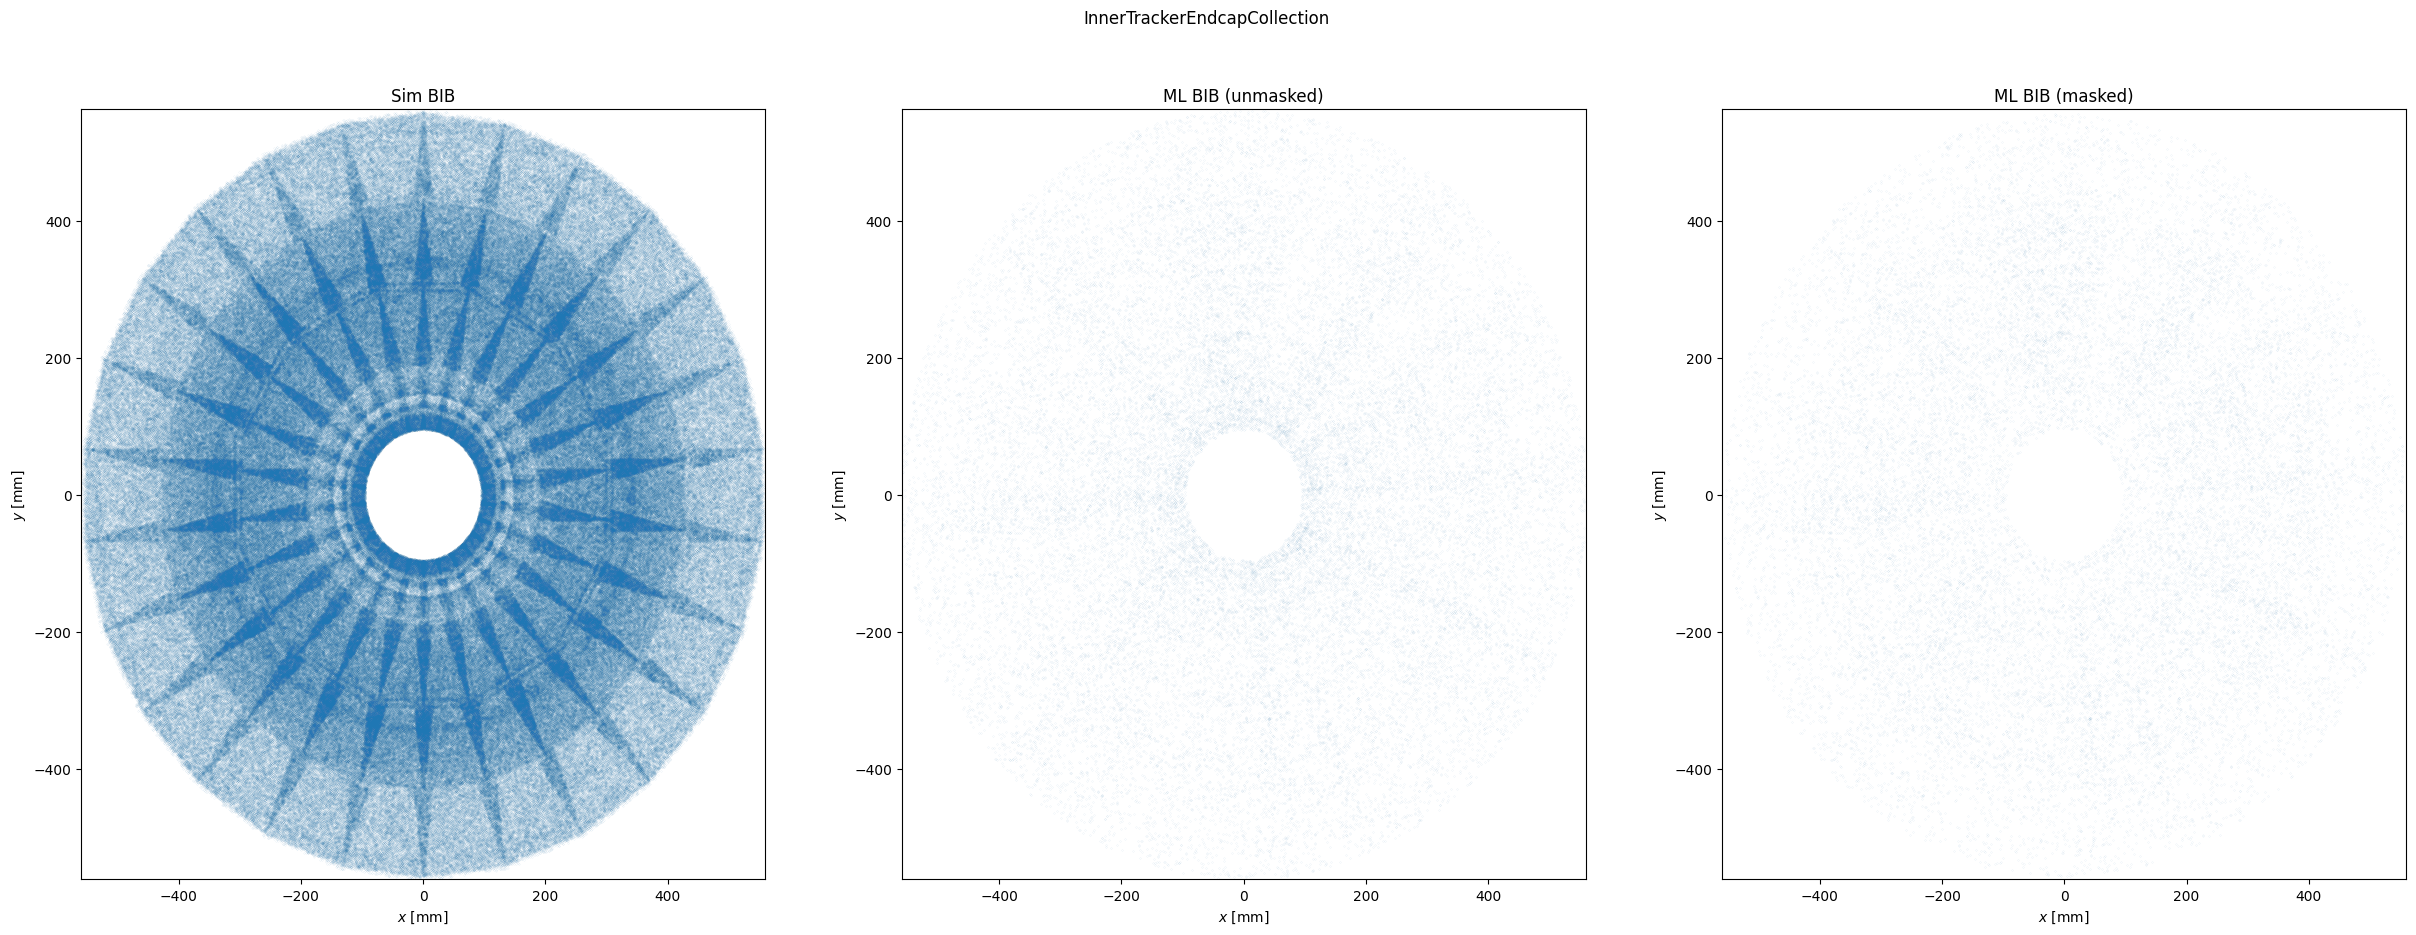

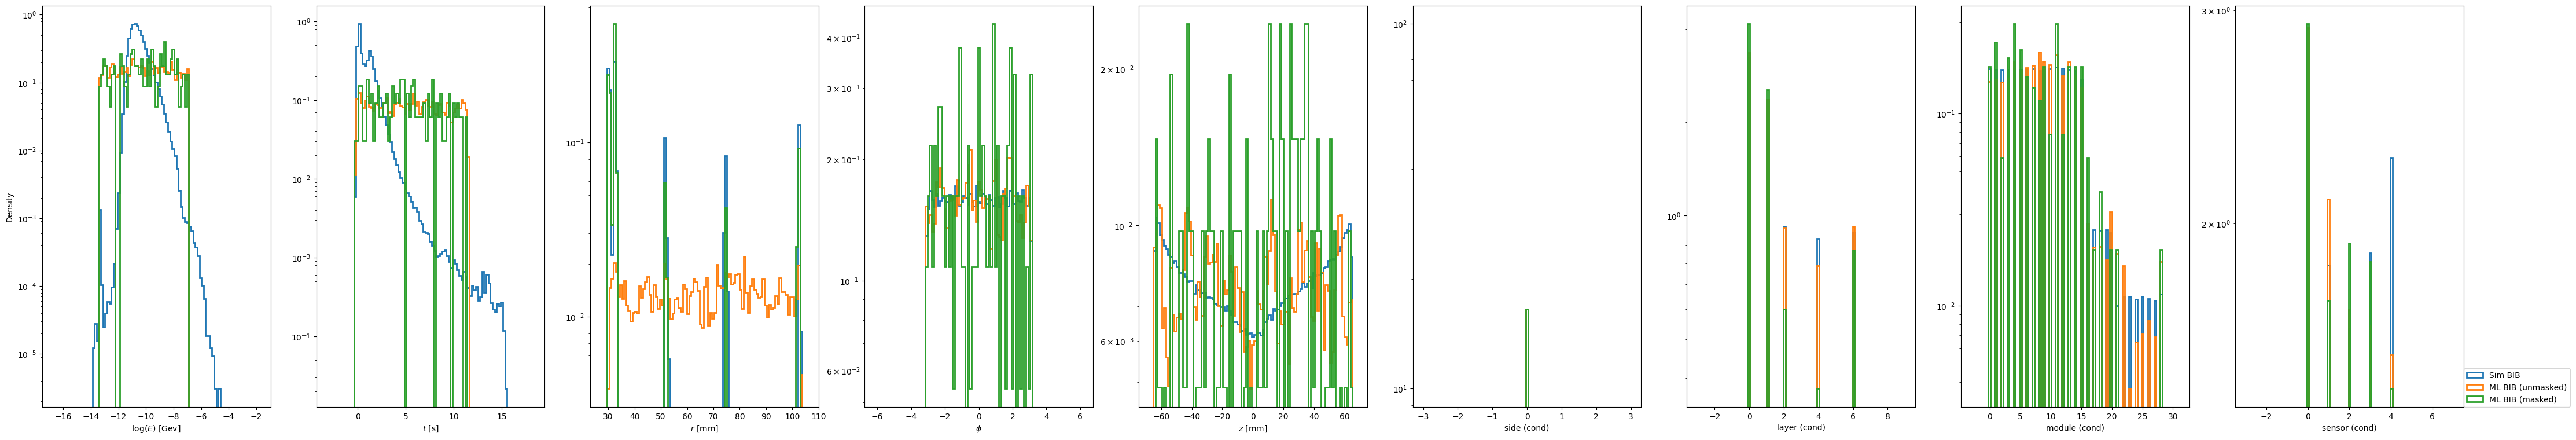

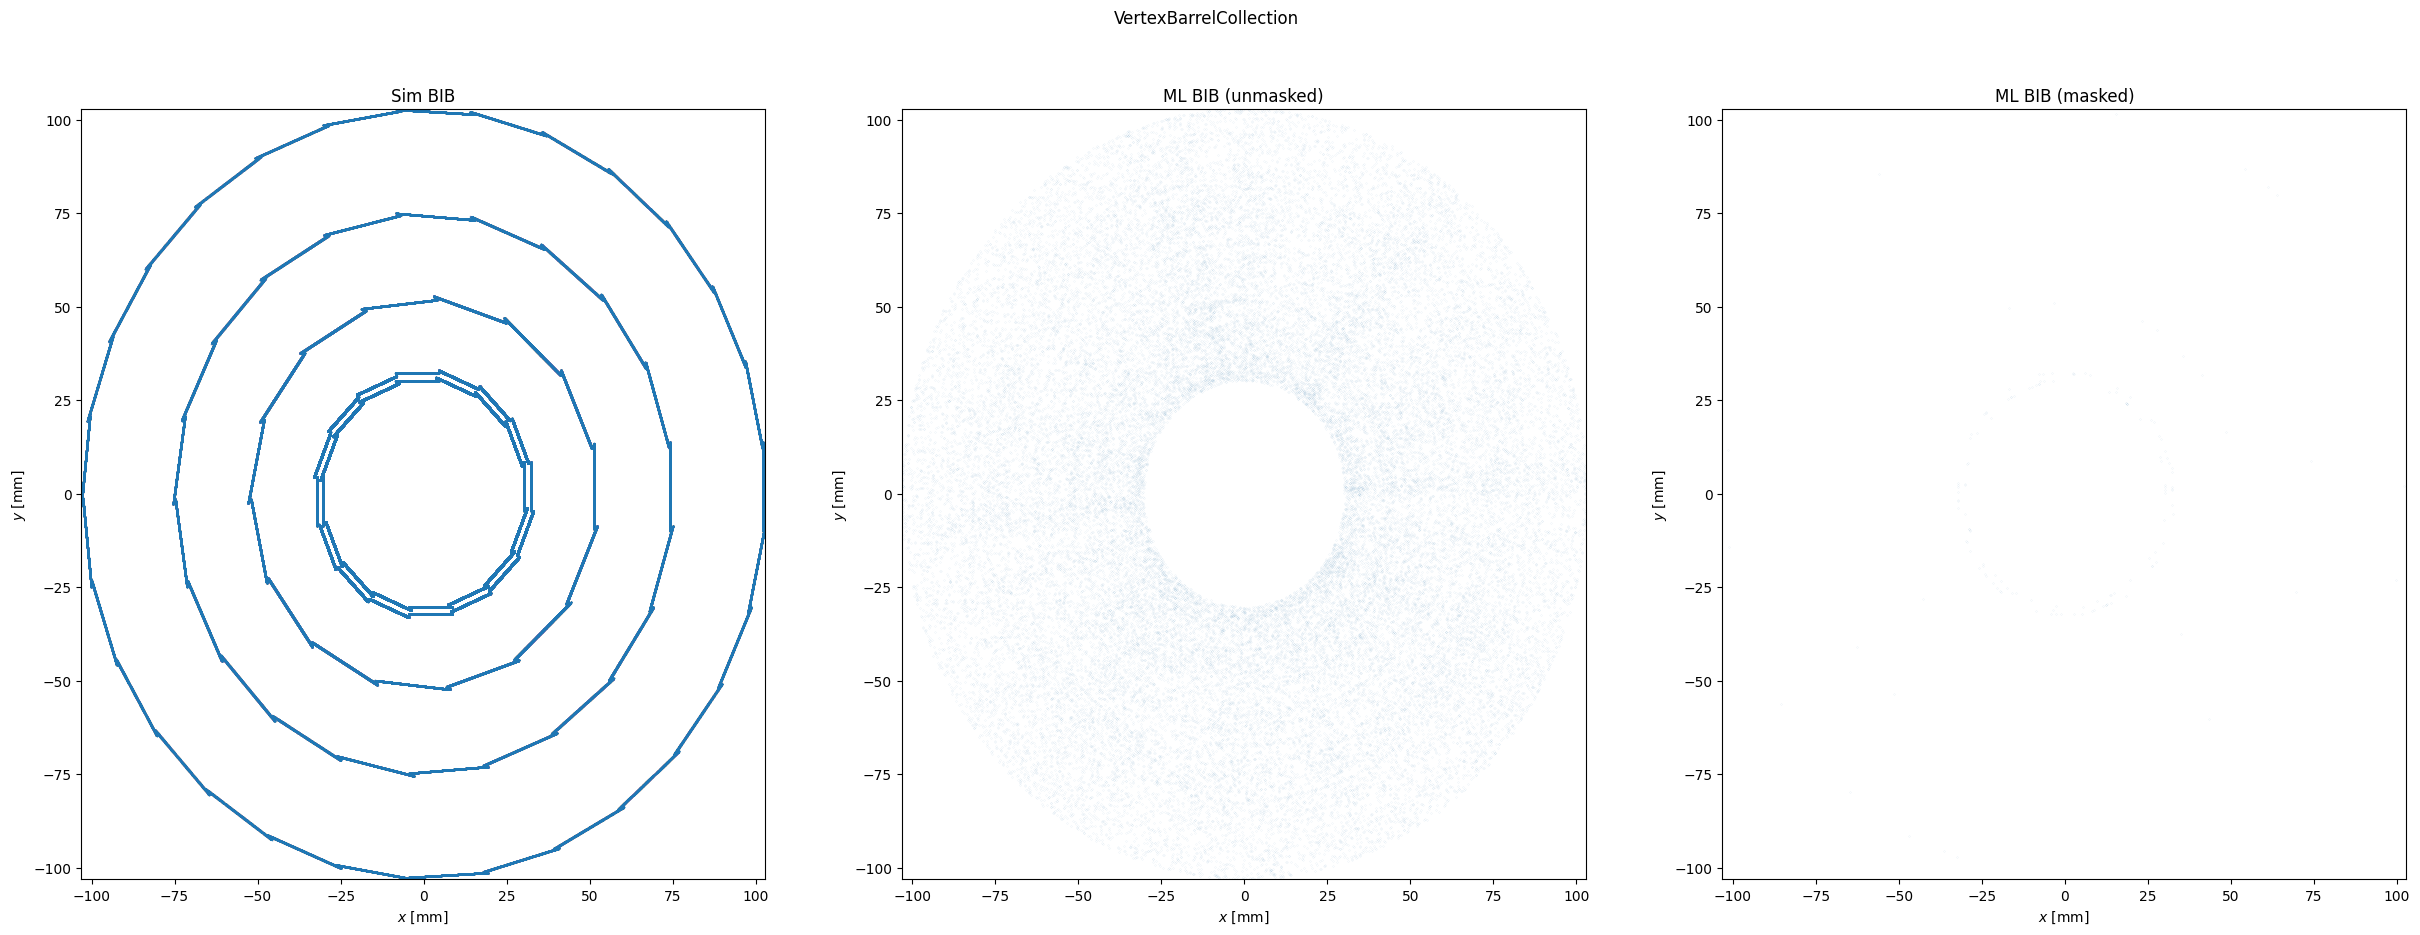

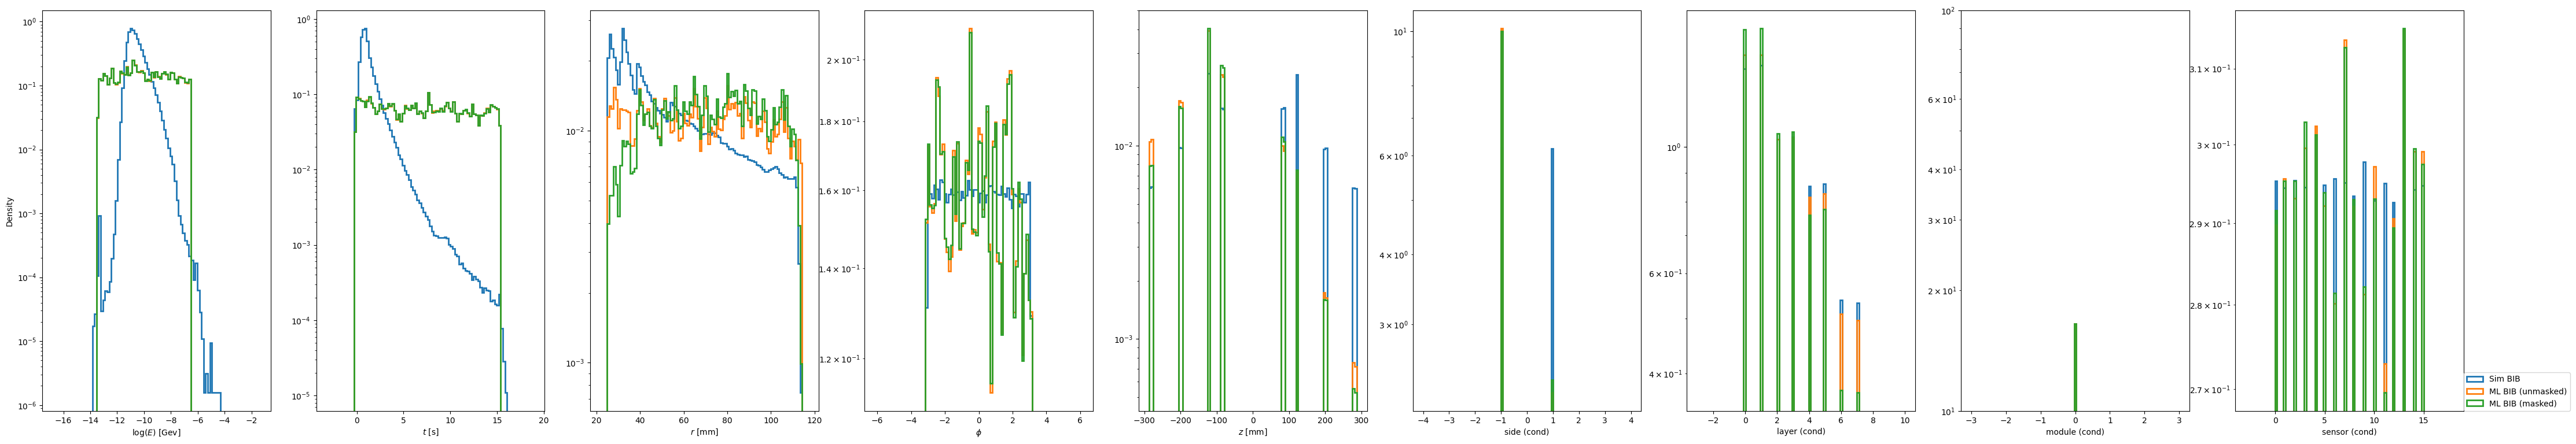

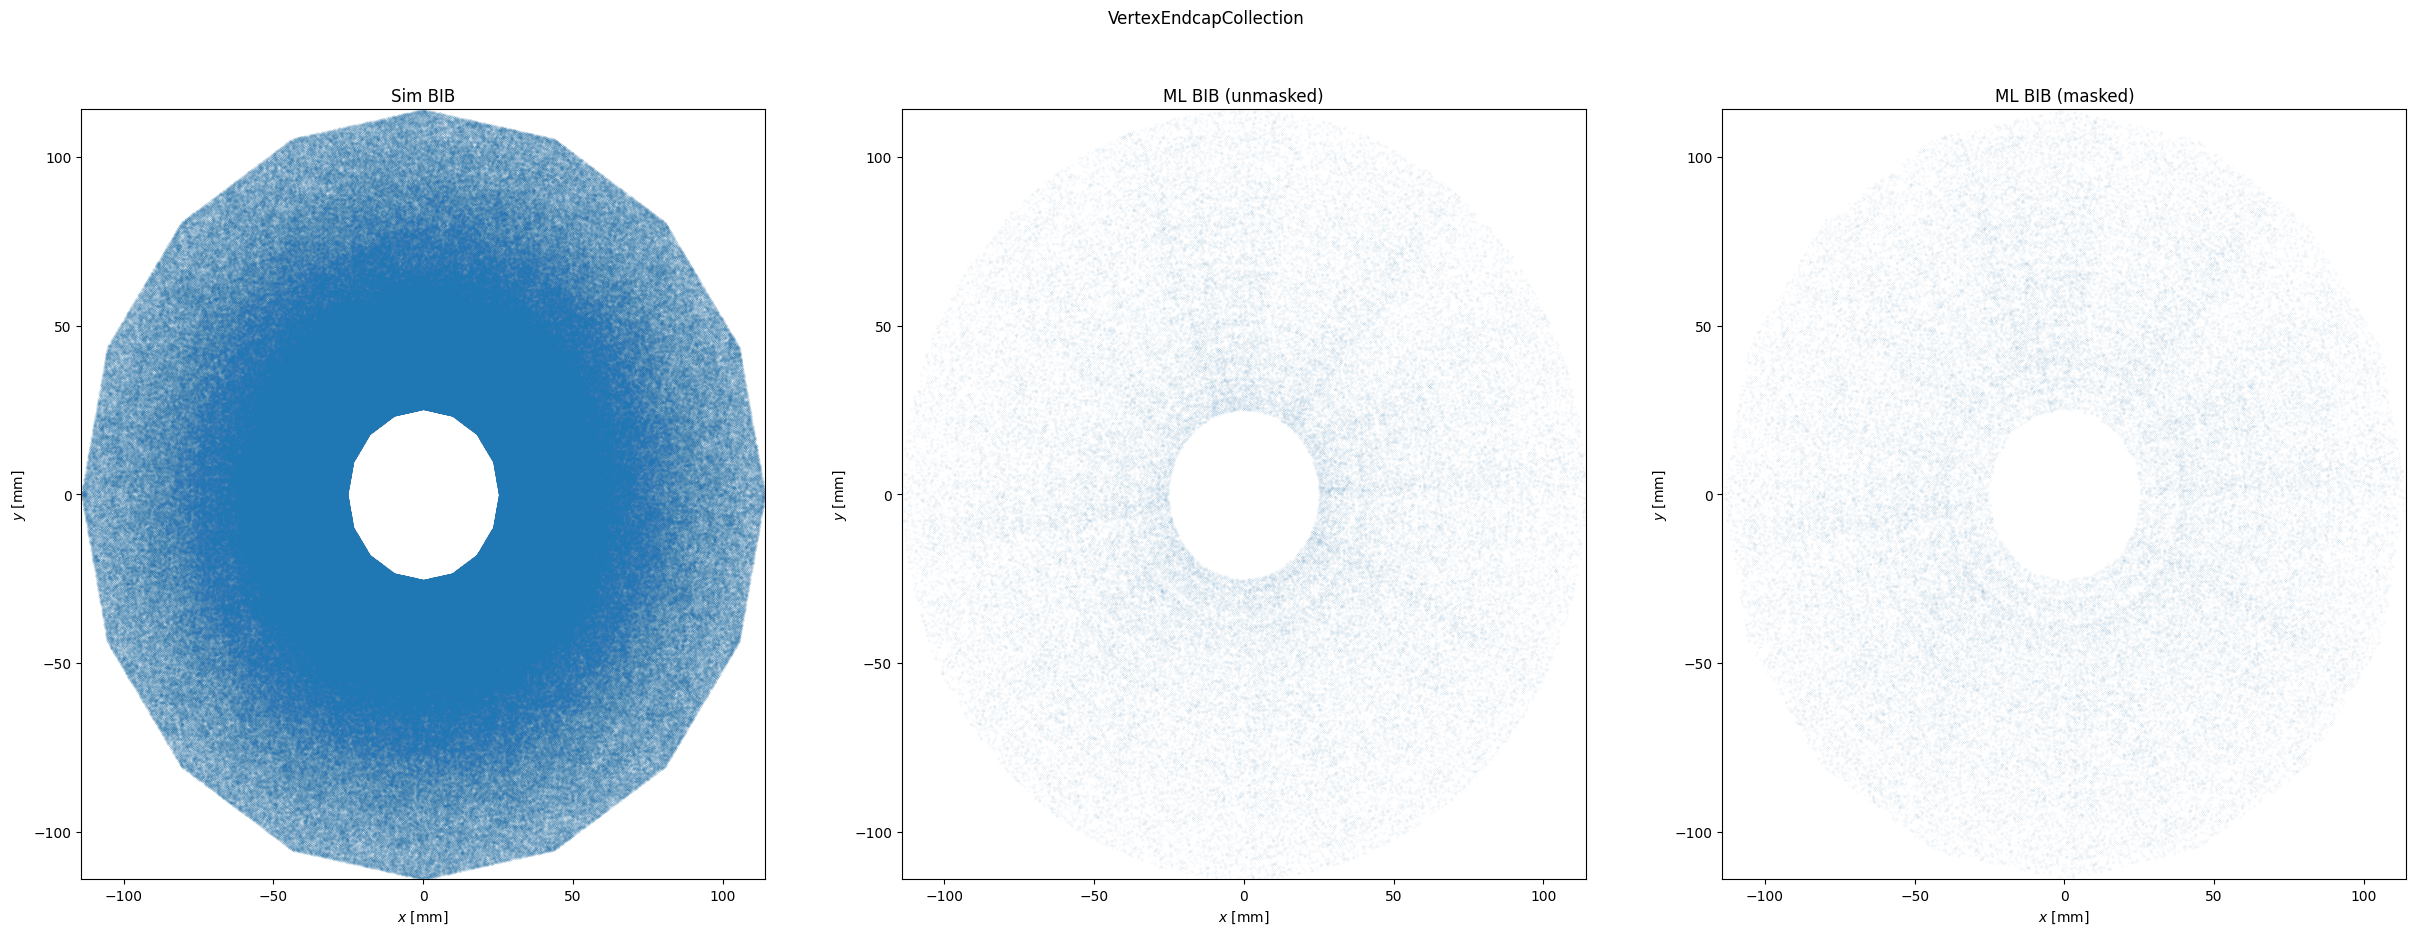

In [8]:

for i, col_name in enumerate(ALL_COLLECTIONS):

   # print(col_name)
    
    
    plot_hists_1d({
        "Sim BIB":all_data_dir[col_name], 
        "ML BIB (unmasked)":  all_samples_dir[col_name],
        "ML BIB (masked)": flow_samples_masked[col_name],
       #  "masked stratified samples": flow_samples_masked_stratified[col_name],
    }, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)


    loc_array = {
        "Sim BIB": (
            all_data_dir[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.cos(all_data_dir[col_name][:, FEATURE_INDICES_DICT["phi"]]),
            all_data_dir[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.sin(all_data_dir[col_name][:, FEATURE_INDICES_DICT["phi"]])
        ),
        "ML BIB (unmasked)": (
            all_samples_dir[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.cos(all_samples_dir[col_name][:, FEATURE_INDICES_DICT["phi"]]),
            all_samples_dir[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.sin(all_samples_dir[col_name][:, FEATURE_INDICES_DICT["phi"]])
        ),
        "ML BIB (masked)": (
            flow_samples_masked[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.cos(flow_samples_masked[col_name][:, FEATURE_INDICES_DICT["phi"]]),
            flow_samples_masked[col_name][:, FEATURE_INDICES_DICT["r"]] *
            np.sin(flow_samples_masked[col_name][:, FEATURE_INDICES_DICT["phi"]])
        ),
        # "masked stratified samples": (
        #     flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["r"]] *
        #     np.cos(flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["phi"]]),
        #     flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["r"]] *
        #     np.sin(flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["phi"]])
        # )
    }

    make_2d_plots(loc_array, ["$x$ [mm]", "$y$ [mm]"], col_name)

    # loc_array = {
    #     "data": (
    #         all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]],
    #         all_data_dir[col_name][:, feature_indices_dict[col_name]["z"]]
    #     ),
    #     "samples": (
    #         all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
    #         all_samples_dir[col_name][:, feature_indices_dict[col_name]["z"]]
    #     ),
    #     "masked samples": (
    #         all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["r"]],
    #         all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["z"]]
    #     )
    # }

    # make_2d_plots(loc_array, ["r", "z"])

In [9]:
single_bdt_results, all_scores, all_plot = {}, {}, {}

import torch
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)


for col_name in ALL_COLLECTIONS:

    print(f"Analyzing {col_name}...")

    

    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 
    
    #indices_1 = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    #indices_2 = np.random.choice(all_samples_dir[col_name].shape[0], size=N, replace=False)
    
    N = np.min([1_000_000, len(flow_samples_masked[col_name])])#flow_samples_masked_stratified[col_name].shape[0]

    
    indices_data = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    indices_flow = np.random.choice(flow_samples_masked[col_name].shape[0], size=N, replace=False)

    tmp = run_eval_suite_BDTs(all_data_dir[col_name][indices_data][:,:-NUM_COND_INPUTS], 
                              {
                                #  "unmasked":all_samples_dir[col_name][indices_flow][:,:-NUM_COND_INPUTS], 
                                  "masked":flow_samples_masked[col_name][indices_flow][:,:-NUM_COND_INPUTS], 
                              # "masked_stratified":flow_samples_masked_stratified[col_name]
                              },
                                bins_dict[col_name],
                              n_cond = 0,
                                device=device,
                                num_BDTs=num_BDTs,
                                plot_suffix=f"_{col_name}",
                             feature_labels=feature_labels_dict[col_name][:-NUM_COND_INPUTS],
                              run_single_feature_BDTs=False
                             
                             )

    single_bdt_results[col_name] = tmp[0]
    all_scores[col_name] = tmp[1]
    all_plot[col_name] = tmp[2]


  #  run_eval_suite_R(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, [0.1, 0.2, 0.4],  100, plot_suffix="")
#
    


Using device: cpu
Analyzing OuterTrackerBarrelCollection...
Len data: 17
Len samples masked: 17


/home/rmastand/muon_collider/helpers/evaluation.py:658: SyntaxWarning: invalid escape sequence '\p'
  print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
/home/rmastand/muon_collider/helpers/evaluation.py:721: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
# all 6 systems at once

import torch
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)

single_bdt_results, all_scores, all_plot = {}, {}, {}

total_data = []
total_samples = []
          
for col_name in ALL_COLLECTIONS:

    mask = apply_material_map_hybrid(all_samples_dir, None, col_name, FEATURE_INDICES_DICT)

    #total_data.append(all_data_dir[col_name][mask])
    total_data.append(all_data_dir[col_name])
    total_samples.append(all_samples_dir[col_name][mask])

    
total_data = np.concatenate(total_data, axis = 0)
total_samples = np.concatenate(total_samples, axis = 0)
print(total_data.shape, total_samples.shape)

   
N = 1_000_000



indices_data = np.random.choice(total_data.shape[0], size=N, replace=False)
indices_flow = np.random.choice(total_samples.shape[0], size=N, replace=False)

tmp = run_eval_suite_BDTs(total_data[indices_data][:,:-NUM_COND_INPUTS], 
                          {
                              #"unmasked":all_samples_dir[col_name][indices_2], 
                           "masked":total_samples[indices_flow][:,:-NUM_COND_INPUTS]
                          },
                            bins_dict[col_name],
                          n_cond = 0,
                            device=device,
                            num_BDTs=num_BDTs,
                            plot_suffix=f"_{col_name}",
                         feature_labels=feature_labels_dict[col_name],
                          run_single_feature_BDTs=False
                         
                         )

single_bdt_results[col_name] = tmp[0]
all_scores[col_name] = tmp[1]
all_plot[col_name] = tmp[2]



In [ ]:

plt.figure()
for i, col_name in enumerate(single_bdt_results.keys()):
    if "Barrel" in col_name:
        for key in single_bdt_results[col_name].keys():
            x_vals = single_bdt_results[col_name][key].keys()
            
            res = [single_bdt_results[col_name][key][x][0] for x in x_vals]
            res_gauss = [single_bdt_results[col_name][key][x][1] for x in x_vals]
            if key == "masked":
                plt.scatter(x_vals, res, color = f"C{i}", label = f"{col_name}, masked", marker="o", s=100)
            elif key == "unmasked":
                plt.scatter(x_vals, res, edgecolor = f"C{i}", label = f"{col_name}, unmasked", marker="o", s=100, facecolor="none")
plt.legend(loc=(1,0))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], labels = feature_labels_dict[col_name], rotation = 45)
plt.xlabel("feature")

plt.ylabel("ROC AUC")
plt.show()

# Analyzing the features that didn't pass

In [ ]:
col_to_analyze = "OuterTrackerBarrelCollection"
percentile_to_analyze = 95
passes =  np.array(all_scores[col_to_analyze]["masked"] >= np.percentile(all_scores[col_to_analyze]["masked"], percentile_to_analyze))


# fig, ax = plt.subplots(1, all_plot[col_to_analyze]["masked"].shape[1], figsize = (30, 5))
# for i in range(all_plot[col_to_analyze]["masked"].shape[1]):
#     ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][~passes], histtype = "step", color = "green", bins = bins_dict[col_to_analyze][i])
#     ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][passes], histtype = "step", color = "red", bins = bins_dict[col_to_analyze][i])
#     ax[i].set_xlabel(feature_labels_dict[col_to_analyze][i])
# plt.show()

plt.figure(figsize = (8, 3))
plt.hist(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]][~passes], histtype = "step", color = "green", bins = np.linspace(816, 824, 2000), density=True)
plt.hist(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]][passes], histtype = "step", color = "red", bins = np.linspace(816, 824, 2000), density=True)
plt.xlabel("$r$ [mm]")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

plt.figure(figsize = (10, 10))
x = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.cos(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
y = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.sin(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
plt.scatter(x[~passes], y[~passes], color = "green", s = 0.1, label = f"below {percentile_to_analyze} percentile")
plt.scatter(x[passes], y[passes], color = "red", s = 0.1, label = f"above {percentile_to_analyze} percentile")
plt.title(f"{col_to_analyze}")
plt.legend(markerscale=10)
plt.xlim(820,825)
plt.ylim(10,45)
plt.xlabel("$x$ [mm]")
plt.ylabel("$y$ [mm]")
plt.show()





In [ ]:
col_to_analyze = "InnerTrackerBarrelCollection"
percentile_to_analyze = 95
passes =  np.array(all_scores[col_to_analyze]["masked"] >= np.percentile(all_scores[col_to_analyze]["masked"], percentile_to_analyze))


# fig, ax = plt.subplots(1, all_plot[col_to_analyze]["masked"].shape[1], figsize = (30, 5))
# for i in range(all_plot[col_to_analyze]["masked"].shape[1]):
#     ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][~passes], histtype = "step", color = "green", bins = bins_dict[col_to_analyze][i])
#     ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][passes], histtype = "step", color = "red", bins = bins_dict[col_to_analyze][i])
#     ax[i].set_xlabel(feature_labels_dict[col_to_analyze][i])
# plt.show()

plt.figure(figsize = (8, 3))
plt.hist(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]][~passes], histtype = "step", color = "green", bins = np.linspace(126, 131, 2000), density=True)
plt.hist(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]][passes], histtype = "step", color = "red", bins = np.linspace(126, 131, 2000), density=True)
plt.xlabel("$r$ [mm]")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

plt.figure(figsize = (10, 10))
x = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.cos(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
y = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.sin(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
plt.scatter(x[~passes], y[~passes], color = "green", s = 0.01, label = f"below {percentile_to_analyze} percentile")
plt.scatter(x[passes], y[passes], color = "red", s = 0.01, label = f"above {percentile_to_analyze} percentile")
plt.title(f"{col_to_analyze}")
plt.legend(markerscale=10)
plt.xlim(125,128)
plt.ylim(-35,-24)
plt.xlabel("$x$ [mm]")
plt.ylabel("$y$ [mm]")
plt.show()





In [ ]:
bb = np.linspace(-1621.855, -1621.8478, 500)

plt.figure(figsize = (10, 4))
plt.hist(all_data_dir[col_name][:,feature_indices_dict[col_name]["z"]], bins = bb, density = True, label = "data", histtype = "stepfilled")



for p in [50]:
    #tmp_masked =  all_plot[col_name]["masked"][all_scores[col_name]["masked"] >= np.percentile(all_scores[col_name]["masked"], p)]
    tmp_unmasked =  all_plot[col_name]["unmasked"][all_scores[col_name]["unmasked"] >= np.percentile(all_scores[col_name]["unmasked"], p)]
    plt.hist(tmp_unmasked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "bad", color = "red")

    tmp_unmasked =  all_plot[col_name]["unmasked"][all_scores[col_name]["unmasked"] <= np.percentile(all_scores[col_name]["unmasked"], p)]
    plt.hist(tmp_unmasked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "good", color = "green")

    plt.axvline(-1621.8538551980234)
    plt.axvline(-1621.8496531597395)
    
   # plt.hist(tmp_masked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "masked")
plt.legend()
plt.yscale("log")
plt.show()

# Nice plots

In [ ]:
# Sim BIB

feature_labels = ["log($E$) [GeV]", "$t$ [s]", "$r$ [mm]", "$\\phi$", "$z$ [mm]", "side", "layer"]
from matplotlib.ticker import NullFormatter

fig, ax = plt.subplots(
    1, 7,
    figsize=(22, 4),
    sharey=False
)

for i in range(7):

    # Common binning across collections
    vals = np.concatenate([
        all_data_dir[col_name][:, i]
        for col_name in collections
    ])
    bins = np.histogram_bin_edges(vals, bins=50)

    for col_name in collections:
        ax[i].hist(
            all_data_dir[col_name][:, i],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=col_name,
        )

    ax[i].set_xlabel(feature_labels[i], fontsize=14)

    ax[i].set_yscale("log")

    # Only left-most panel gets y label
    if i == 0:
        ax[i].set_ylabel("Density", fontsize=14)
    else:
        ax[i].yaxis.set_tick_params(labelleft=False)
        ax[i].yaxis.set_ticklabels([])  # explicitly clear tick labels
        ax[i].yaxis.set_major_formatter(NullFormatter())
        ax[i].yaxis.set_minor_formatter(NullFormatter())

    ax[i].tick_params(labelsize=12)
    

# Single legend above all panels
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.65, 1.05),
    ncol=3,
    frameon=False,
    fontsize=14,
)

# Reduce spacing between panels
plt.subplots_adjust(
    # left=0.06,
    # right=0.995,
    # bottom=0.18,
    # top=0.78,
    wspace=0.05,
)

plt.show()





In [ ]:

plt.figure()
for col_name in collections:
    plt.scatter(np.abs(all_data_dir[col_name][:1000000,4]), all_data_dir[col_name][:1000000,2], label = col_name, s = 0.00001)

plt.ylabel("$r$ [mm]", fontsize = 14)
plt.xlabel("$|z|$ [mm]", fontsize = 14)
plt.gca().set_aspect("equal", adjustable="box")

plt.legend(markerscale=1000, loc = (1,0), fontsize = 14)
plt.show()


In [ ]:
# ML BIB: per-collection data vs flow + ratio

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter


n_bins = 50
eps = 1e-12

for col_name in collections:

    fig, ax = plt.subplots(
        2, 7,
        figsize=(22, 5),
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    for i in range(7):

        data_vals = all_data_dir[col_name][:, i]
        flow_vals = flow_samples_masked[col_name][:, i]

        # Common binning for data + flow in this collection/feature
        vals = np.concatenate([data_vals, flow_vals])
        bins = np.histogram_bin_edges(vals, bins=n_bins)

        # Histogram values for ratio
        data_hist, _ = np.histogram(data_vals, bins=bins, density=True)
        flow_hist, _ = np.histogram(flow_vals, bins=bins, density=True)

        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        ratio = np.divide(
            flow_hist,
            data_hist,
            out=np.full_like(flow_hist, np.nan, dtype=float),
            where=data_hist > eps,
        )

        # -------------------------
        # Top: densities
        # -------------------------
        ax[0, i].hist(
            data_vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label="Sim BIB",
        )

        ax[0, i].hist(
            flow_vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label="ML BIB",
        )

        ax[0, i].set_yscale("log")

        if i == 0:
            ax[0, i].set_ylabel("Density", fontsize=14)
        else:
            ax[0, i].yaxis.set_tick_params(labelleft=False)
            ax[0, i].yaxis.set_ticklabels([])
            ax[0, i].yaxis.set_major_formatter(NullFormatter())
            ax[0, i].yaxis.set_minor_formatter(NullFormatter())

        ax[0, i].tick_params(labelsize=10)

        # -------------------------
        # Bottom: flow / data ratio
        # -------------------------
        ax[1, i].axhline(1.0, linestyle="--", linewidth=1)

        ax[1, i].step(
            bin_centers,
            ratio,
            where="mid",
            linewidth=1.5,
            color = "k"
        )

        ax[1, i].set_xlabel(feature_labels[i], fontsize=14)

        if i == 0:
            ax[1, i].set_ylabel("ML/Sim", fontsize=14)
        else:
            ax[1, i].yaxis.set_tick_params(labelleft=False)
            ax[1, i].yaxis.set_ticklabels([])

        ax[1, i].tick_params(labelsize=12)

    # Single legend above panels
    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.7, 1.0),
        ncol=2,
        frameon=False,
        fontsize=14,
    )

    fig.suptitle(col_name, fontsize=14)#, y=1.0)

    plt.subplots_adjust(
        wspace=0.05,
        #top=0.88,
    )

    plt.show()

## Save out samples

In [ ]:
# make the samples dir if it doesn't exist

PATH_TO_SAVE_SAMPLES = "/scratch/midway3/rmastand/muon_collider/zuko_outputs/combined_samples/"
if not os.path.exists(PATH_TO_SAVE_SAMPLES):
    os.makedirs(PATH_TO_SAVE_SAMPLES)

In [ ]:
hits_dict_inside_bounds = {
    "OuterTrackerBarrelCollection":3_280_678,
    "OuterTrackerEndcapCollection":1_465_825,
    "InnerTrackerBarrelCollection":3_926_196,
    "InnerTrackerEndcapCollection":1_614_679,
    "VertexBarrelCollection":2_129_166,
    "VertexEndcapCollection":4_096_371,
}

hits_dict_no_condition = {
    "OuterTrackerBarrelCollection":6_787_500,
    "OuterTrackerEndcapCollection":2_825_825,
    "InnerTrackerBarrelCollection":6_639_439,
    "InnerTrackerEndcapCollection":2_360_215,
    "VertexBarrelCollection":2_641_857,
    "VertexEndcapCollection":5_325_807,
}

for col in ALL_COLLECTIONS:

    print(col)

    n_samples = hits_dict_no_condition[col]

    idx = np.random.choice(len(flow_samples_masked[col]), size=n_samples, replace=False)

    loc_subset = flow_samples_masked[col][idx]

    print("flow samples", loc_subset.shape)
    np.save(f"{PATH_TO_SAVE_SAMPLES}/{col}.npy", loc_subset)

    #print(loc.shape,)